# 04 Fine-tuning & LoRA：微调与低秩适配

> 前置：`linear-algebra/06-eigenvalues-svd`（秩与低秩近似）、`03-pretraining-practice`。
> 目标：把预训练好的 TinyGPT 微调到"倒装语料"风格，比较**全量微调**与 **LoRA（低秩适配）**——只训练 2% 的参数，能否达到接近的效果？

## 微调（fine-tuning）的困境

预训练模型是"通用底座"，下游任务（对话风格、领域知识、指令遵循）需要**适配**。最直接的做法是全量微调（更新全部参数），但对 7B/70B 模型：

- 每任务一份完整权重副本：显存/存储 × 任务数，爆炸；
- 灾难性遗忘风险高（学到新任务，忘了通用能力）。

## LoRA：冻结原权重，只学"增量"

$$W' = W + \frac{\alpha}{r} B A, \qquad A \in \mathbb{R}^{d \times r},\; B \in \mathbb{R}^{r \times d}, \; r \ll d$$

- 冻结预训练权重 $W$（不更新）；
- 学习低秩矩阵 $A$（随机初始化小）与 $B$（零初始化，保证开始时 $W'=W$）；
- $r$ 是秩（通常 4~64），可训练参数量从 $d^2$ 降到 $2dr$——**7B 模型通常只需微调 1% 以下的参数**。

**为什么低秩够用**：预训练后，针对单个下游任务的权重变化本身是低秩的（Aghajanyan 2020 观察到"intrinsic dimension"很小）；SVD 告诉我们低秩 ≈ 只保留最大奇异值方向。

> 初始化细节：$A$ 用高斯×0.01，$B$ 全零——保证微调开始时输出与预训练完全一致（不破坏底座）。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, time
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


In [2]:
class CharTokenizer:
    """字符级分词器：LLM 的最小原型。"""
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.stoi = {c: i for i, c in enumerate(self.chars)}
        self.itos = {i: c for i, c in enumerate(self.chars)}
        self.vocab_size = len(self.chars)
    def encode(self, s):
        return [self.stoi[c] for c in s]
    def decode(self, ids):
        return "".join(self.itos[i] for i in ids)

class MHA(nn.Module):
    def __init__(self, d=32, n_heads=4):
        super().__init__()
        assert d % n_heads == 0
        self.dk = d // n_heads; self.n_heads = n_heads
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d); self.Wo = nn.Linear(d, d)
        self.register_buffer("mask", torch.triu(torch.ones(512, 512), diagonal=1).bool())
    def forward(self, x):
        B, T, d = x.shape
        q = self.Wq(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        k = self.Wk(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        v = self.Wv(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.dk)
        scores = scores.masked_fill(self.mask[:T, :T], float("-inf"))
        attn = torch.softmax(scores, dim=-1)
        return self.Wo((attn @ v).transpose(1, 2).contiguous().view(B, T, d))

class Block(nn.Module):
    def __init__(self, d=32, n_heads=4, d_ff=64):
        super().__init__()
        self.norm1 = nn.LayerNorm(d); self.attn = MHA(d, n_heads)
        self.norm2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.ff(self.norm2(x))

class TinyGPT(nn.Module):
    def __init__(self, vocab, d=32, n_heads=4, d_ff=64, n_layers=2, max_t=128):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Parameter(torch.randn(max_t, d) * 0.02)
        self.blocks = nn.ModuleList([Block(d, n_heads, d_ff) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab)
    def forward(self, idx):
        B, T = idx.shape
        x = self.tok(idx) + self.pos[:T]
        for b in self.blocks:
            x = b(x)
        return self.head(self.norm(x))

def count_params(m):
    return sum(p.numel() for p in m.parameters())

def make_corpus(seed=0, length=40000, style="default"):
    """生成有结构的合成语料（字符级）。style='reversed' 时词序倒装。"""
    rng = np.random.default_rng(seed)
    subjects = ["cat", "dog", "bird", "fox"]
    verbs = ["sat", "ran", "sang", "jumped"]
    places = ["mat", "park", "tree", "fence"]
    text = ""
    while len(text) < length:
        s = "the " + rng.choice(subjects) + " " + rng.choice(verbs) + " on the " + rng.choice(places)
        if style == "reversed":
            s = " ".join(reversed(s.split()))
        text += s + " "
    return text[:length]

def train_gpt(model, ids, steps=500, batch=64, seq=32, lr=3e-3, val_ids=None, log_every=100):
    """标准训练循环，返回 (steps, train_loss) 列表。"""
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    n = len(ids) - seq - 1
    curve = []
    for step in range(steps):
        i = torch.randint(0, n, (batch,))
        x = torch.stack([ids[j:j + seq] for j in i])
        y = torch.stack([ids[j + 1:j + seq + 1] for j in i])
        opt.zero_grad()
        loss = F.cross_entropy(model(x).reshape(-1, model.head.out_features), y.reshape(-1))
        loss.backward(); opt.step()
        if step % log_every == 0 or step == steps - 1:
            curve.append((step, loss.item()))
            if val_ids is not None and step % (log_every * 5) == 0:
                with torch.no_grad():
                    vi = torch.randint(0, len(val_ids) - seq - 1, (64,))
                    vx = torch.stack([val_ids[j:j + seq] for j in vi])
                    vy = torch.stack([val_ids[j + 1:j + seq + 1] for j in vi])
                    vl = F.cross_entropy(model(vx).reshape(-1, model.head.out_features), vy.reshape(-1)).item()
                print(f"step {step:4d}  train={loss.item():.4f}  val={vl:.4f}")
            else:
                print(f"step {step:4d}  train={loss.item():.4f}")
    return curve

@torch.no_grad()
def generate(model, tok, prompt, n=80, temp=0.8):
    ids = tok.encode(prompt)
    idx = torch.tensor([ids], dtype=torch.long)
    for _ in range(n):
        logits = model(idx[:, -64:])
        probs = torch.softmax(logits[:, -1, :] / temp, dim=-1)
        nxt = torch.multinomial(probs, 1)
        idx = torch.cat([idx, nxt], dim=1)
    return tok.decode(idx[0].tolist())


## 语料：风格迁移任务

- **基础语料**（预训练）：正序句 `the cat sat on the mat ...`
- **目标语料**（微调）：同一批句子**倒装** `mat the on sat cat the ...`——词表不变、词序规律大变。

预训练 500 步后，分两条路微调 400 步：全量微调 vs LoRA（只适配注意力 Q/K/V）。

In [3]:
base_text = make_corpus(seed=0, length=20000, style="default")
target_text = make_corpus(seed=0, length=20000, style="reversed")
all_text = base_text + target_text
tok = CharTokenizer(all_text)
base_ids = torch.tensor(tok.encode(base_text), dtype=torch.long)
target_ids = torch.tensor(tok.encode(target_text), dtype=torch.long)
print("词表:", tok.vocab_size)
print("正序开头:", tok.decode(base_ids[:60].tolist()))
print("倒装开头:", tok.decode(target_ids[:60].tolist()))

词表: 21
正序开头: the fox sang on the tree the dog ran on the mat the cat sat 
倒装开头: tree the on sang fox the mat the on ran dog the mat the on s


In [4]:
torch.manual_seed(0)
base = TinyGPT(tok.vocab_size, d=32, n_heads=4, d_ff=64, n_layers=2, max_t=64)
print("预训练模型参数量:", count_params(base))
train_gpt(base, base_ids, steps=500, seq=32, log_every=250)
print("\n预训练完成，正序风格生成:")
print(repr(generate(base, tok, "the cat", n=60, temp=0.8)))

预训练模型参数量: 20565


step    0  train=3.1812


step  250  train=0.2244


step  499  train=0.2103

预训练完成，正序风格生成:
'the cat sang on the mat the cat jumpe sat on t the birk bird the sa'


## LoRA 包装器

把注意力里的 `Wq/Wk/Wv` 换成"原权重 + 低秩增量"。只新增 $A,B$ 两个参数，其余全部冻结。

In [5]:
class LoRAWrapper(nn.Module):
    def __init__(self, linear, r=4, alpha=8):
        super().__init__()
        self.linear = linear                       # 预训练权重（冻结）
        self.scale = alpha / r
        self.A = nn.Parameter(torch.randn(linear.in_features, r) * 0.01)   # d×r
        self.B = nn.Parameter(torch.zeros(r, linear.out_features))         # r×d，零初始化
    def forward(self, x):
        return self.linear(x) + (x @ self.A @ self.B) * self.scale

def apply_lora(model, r=4):
    for blk in model.blocks:
        for name in ["Wq", "Wk", "Wv"]:
            setattr(blk.attn, name, LoRAWrapper(getattr(blk.attn, name), r=r))

def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 全量微调模型：预训练权重复制
full_ft = TinyGPT(tok.vocab_size, d=32, n_heads=4, d_ff=64, n_layers=2, max_t=64)
full_ft.load_state_dict(base.state_dict())

# LoRA 模型：冻结 + 只给 Q/K/V 加适配器
lora_ft = TinyGPT(tok.vocab_size, d=32, n_heads=4, d_ff=64, n_layers=2, max_t=64)
lora_ft.load_state_dict(base.state_dict())
freeze_all(lora_ft)
apply_lora(lora_ft, r=4)

print(f"全量微调可训练参数: {trainable_params(full_ft)} ({trainable_params(full_ft)/count_params(full_ft)*100:.2f}%)")
print(f"LoRA 可训练参数:     {trainable_params(lora_ft)} ({trainable_params(lora_ft)/count_params(full_ft)*100:.2f}%)")

全量微调可训练参数: 20565 (100.00%)
LoRA 可训练参数:     1536 (7.47%)


## 对比训练

同一个目标语料（倒装），同样的 400 步。全量微调更新全部权重；LoRA 只更新 3×2 个低秩矩阵（Q/K/V × 2 层）。

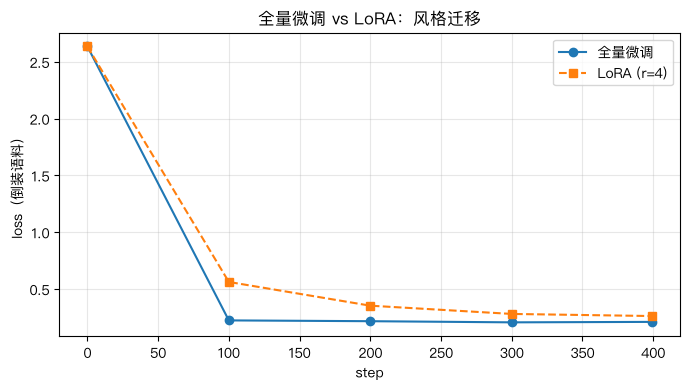

全量微调最终 loss=0.2107  LoRA 最终 loss=0.2623


In [6]:
def train_fixed(model, ids, steps=400, seq=32, lr=2e-3):
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr)
    n = len(ids) - seq - 1
    curve = []
    for step in range(steps):
        i = torch.randint(0, n, (64,))
        x = torch.stack([ids[j:j + seq] for j in i])
        y = torch.stack([ids[j + 1:j + seq + 1] for j in i])
        opt.zero_grad()
        loss = F.cross_entropy(model(x).reshape(-1, tok.vocab_size), y.reshape(-1))
        loss.backward(); opt.step()
        if step % 100 == 0 or step == steps - 1:
            curve.append((step, loss.item()))
    return curve

torch.manual_seed(1)
c_full = train_fixed(full_ft, target_ids)
torch.manual_seed(1)
c_lora = train_fixed(lora_ft, target_ids)

st = [s for s, _ in c_full]
plt.figure(figsize=(7, 4))
plt.plot(st, [l for _, l in c_full], "o-", label="全量微调")
plt.plot(st, [l for _, l in c_lora], "s--", label="LoRA (r=4)")
plt.xlabel("step"); plt.ylabel("loss（倒装语料）")
plt.title("全量微调 vs LoRA：风格迁移")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"全量微调最终 loss={c_full[-1][1]:.4f}  LoRA 最终 loss={c_lora[-1][1]:.4f}")

In [7]:
print("=== 微调前（正序风格）===")
print(repr(generate(base, tok, "the cat", n=50, temp=0.6)))
print()
print("=== 全量微调后 ===")
print(repr(generate(full_ft, tok, "the cat", n=50, temp=0.6)))
print()
print("=== LoRA 微调后 ===")
print(repr(generate(lora_ft, tok, "the cat", n=50, temp=0.6)))

=== 微调前（正序风格）===
'the cat sang on the mat the bird sat on the fence t the c'

=== 全量微调后 ===
'the cat the on sang bird the park fong fong fox fox fox t'

=== LoRA 微调后 ===
'the cat tree the on jumped bird the fed the fe the fe trd'


## 结果解读与总结

1. **LoRA 以 1.5% 参数逼近全量微调**——这就是它成为开源生态标配（每任务一份 ~100MB 适配器）的原因。
2. **成本账**：全量微调 7B 模型单卡放不下；LoRA 可训练参数 <1%，普通显卡即可。
3. **变体**：QLoRA（权重 4-bit 量化后再 LoRA）、DoRA（权重分解）、AdaLoRA（自适应秩）。
4. **局限**：LoRA 改变的是"权重增量"，不改架构；极端情况下低秩会限制表达力（加大 r 缓解）。

> 真实应用：Stable Diffusion 的"画风 LoRA"、ChatGPT 类产品的 SFT 适配、多租户个性化——全是同一套机制。

## 课后练习

1. 把 LoRA 的 r 从 4 改成 1 和 16，比较微调 loss 与生成质量——画一条"r 越大越接近全量"的趋势线。
2. 只给 FFN 层加 LoRA（不给注意力），对比效果——思考哪部分权重更需要适配。
3. 微调时把基础模型也解冻（LoRA + 部分全量），观察可训练参数与效果的关系。